## Project Overview

### Business Problem
A company want to create a new movie studio but it doesn't know anything about creating it. This project investigates which types of films are currently performing best at the global box office, with the goal of translating these findings into actionable insights for the head of our company’s new movie studio. The analysis will explore how production budgets, audience preferences, and critical reception interact to shape financial outcomes, ultimately guiding investment decisions toward maximizing profitability.
### Business Understanding.
### 1. Objectives
* Return on investment: Aim is to maximize return on investment by producing films that will generate high revenue compared with production costs. Assess the relationship between production spending and box office returns to determine optimal investment strategies.
* Movie popularity: The aim will be to produce films with high audience demand to maximize viewership and increase revenues. Use IMDb and TheMovieDB data to track popularity, genre preferences, and viewer behavior.
* Reviews and Ratings: The quality of  films have an impact on the reputation of a start-up studio brand, reducing the revenues in long term. Incorporate Rotten Tomatoes scores to evaluate whether critic ratings influence box office success.
* Seasonality: We will aim to find the season that will maximize revenues. Use the Box office Mojo dataset.

### 2. Methodology
* Data integration: Combine financial performance metrics with audience and critic insights from IMDb, TheMovieDB, and Rotten Tomatoes.
* Comparative analysis: Contrast films across genres, budget ranges, and reception levels to identify patterns of profitability.
* Strategic recommendations: Translate findings into clear guidance on what types of films to prioritize, and how to align production budgets with audience demand.

### 3. Expected Outcomes
The project will deliver evidence-based recommendations for film investment. These insights will help the studio strategically allocate resources, balancing creative ambition with commercial viability to maximize returns.

### Data understanding

Different datasets were collected from different locations and the datasets are in different format and contains different data.

The datasets used in this project include:

* Box Office Mojo: This dataset provides information on domestic and international box office revenues for films. It is essential for evaluating financial performance and identifying high-grossing movies.

* IMDb: The IMDb dataset contains movie metadata, including genre classifications, runtime duration, release year, and audience ratings. These variables help analyze how film characteristics influence box office outcomes.

* Rotten Tomatoes: This dataset includes critic and audience review scores, which are used to assess how film quality and reception impact commercial success.

* TheMovieDB: TheMovieDB dataset provides additional movie attributes such as popularity scores, release dates, and audience engagement indicators. These metrics help evaluate market demand and viewer preferences.

* The Numbers: This dataset contains production budget and worldwide gross revenue information, which is critical for calculating profitability and return on investment (ROI).

### Data Preparation
The datasets used in this project come from multiple sources, each with different formats and structures. Before analysis, the data must be cleaned, standardized, and merged.



### Importing Libraries


In [56]:
# Importing necessary libraries
import pandas as pd
import sqlite3
import zipfile
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_theme(style="whitegrid")

### Loading Datasets

In [57]:
# Load datasets

# Box Office Mojo(domestic and foreign gross dataset)
bom = pd.read_csv("data/bom.movie_gross.csv.gz")

# The Numbers (budget dataset)
budget = pd.read_csv("data/tn.movie_budgets.csv.gz")

# We will be working with the IMDb datasets,
# so we will connect to the SQLite database and check the tables.
# Exract zipfile
with zipfile.ZipFile("data/im.db.zip", 'r') as zip_ref:
    zip_ref.extractall("data/")
# connect to database
conn = sqlite3.connect("data/im.db") 

#The MovieDB (movie opularity)
movie_db =pd.read_csv("data/tmdb.movies.csv.gz")

#Rotten Tomatoes (Audience review scores)
rotten_tomatoes = pd.read_csv("data/rt.movie_info.tsv.gz", sep='\t')





### Data Exploration & Data Cleaning

 In this section, we will inspect each dataset, and clean them separately for analysis.

### 1. Box Office Mojo Dataset

Data Exploration

In [58]:
bom.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


In [59]:
bom.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [60]:
bom.isnull().sum()

title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

In [61]:
bom.duplicated().sum()

np.int64(0)

Data Cleaning

In [62]:
# Cleaning the box office data
# We will drop rows with missing values in critical columns 
# (the 'title', 'domestic_gross', 'foreign_gross') 
# and convert the gross columns to numeric types for analysis.
bom = bom.dropna(subset=["title", "studio", "domestic_gross", "foreign_gross"])
bom.columns = bom.columns.str.lower().str.replace(" ", "_")
bom['domestic_gross'] = pd.to_numeric(bom['domestic_gross'], errors='coerce')
bom['foreign_gross'] = pd.to_numeric(bom['foreign_gross'], errors='coerce')

### 2. The Numbers Dataset

Exploration

In [63]:
budget.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB


In [64]:
budget.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [65]:
budget.isnull().sum()

id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64

In [66]:
budget.duplicated().sum()

np.int64(0)

Data Cleaning

In [67]:
# Remove dollar signs and commas from production_budget, domestic_gross and worldwide_gross 
# using raw strings, then convert to float
budget['production_budget'] = budget['production_budget'].replace(r'[\$,]', '', regex=True).astype(float)
budget['domestic_gross'] = budget['domestic_gross'].replace(r'[\$,]', '', regex=True).astype(float)
budget['worldwide_gross'] = budget['worldwide_gross'].replace(r'[\$,]', '', regex=True).astype(float)
budget['release_date'] = pd.to_datetime(budget['release_date'], errors='coerce')



In [68]:
budget.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 5782 non-null   int64         
 1   release_date       5782 non-null   datetime64[ns]
 2   movie              5782 non-null   object        
 3   production_budget  5782 non-null   float64       
 4   domestic_gross     5782 non-null   float64       
 5   worldwide_gross    5782 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 271.2+ KB


### 3. Imdb Dataset

Data Exploration

In [69]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [70]:
# Load the relevant tables into pandas DataFrames
# We will load the `movie_basics` and `movie_ratings` tables from the IMDb database, 
# which contain information about movie titles, release years, genres, and ratings.
titles = pd.read_sql("SELECT * FROM movie_basics", conn)
ratings = pd.read_sql("SELECT * FROM movie_ratings", conn)

In [71]:
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146144 entries, 0 to 146143
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   movie_id         146144 non-null  object 
 1   primary_title    146144 non-null  object 
 2   original_title   146123 non-null  object 
 3   start_year       146144 non-null  int64  
 4   runtime_minutes  114405 non-null  float64
 5   genres           140736 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 6.7+ MB


In [72]:
titles.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [73]:
titles.isnull().sum()

movie_id               0
primary_title          0
original_title        21
start_year             0
runtime_minutes    31739
genres              5408
dtype: int64

In [74]:
titles.duplicated().sum()


np.int64(0)

In [75]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73856 entries, 0 to 73855
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   movie_id       73856 non-null  object 
 1   averagerating  73856 non-null  float64
 2   numvotes       73856 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 1.7+ MB


In [76]:
ratings.head()

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [77]:
ratings.isnull().sum()

movie_id         0
averagerating    0
numvotes         0
dtype: int64

In [78]:
ratings.duplicated().sum()

np.int64(0)

Data Cleaning

In [79]:

titles = titles.dropna(subset=["original_title", "runtime_minutes", "genres"])


### Data Analysis

#### Business Questions


### 1. Reviews and Ratings

Do higher critic scores (Imdb) lead to higher box office revenue?

In [80]:
# Merge the titles and ratings DataFrames on the `movie_id` 
# column to create a single DataFrame that contains all relevant information about each movie.
imdb = pd.merge(titles, ratings, on='movie_id', how='inner')
imdb.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama",7.0,77
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama",7.2,43
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama,6.9,4517
3,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy",6.5,119
4,tt0137204,Joe Finds Grace,Joe Finds Grace,2017,83.0,"Adventure,Animation,Comedy",8.1,263


In [81]:
# Rename columns for clarity and consistency with the Box Office Mojo dataset
imdb = imdb.rename(columns={
    'primary_title': 'title',
    'start_year': 'year',
    'runtime_minutes': 'runtime',
    'averagerating': 'rating',
    'numvotes': 'votes'
})
# Check the first few rows of the merged DataFrame to ensure everything looks correct
imdb.head()

,movie_id,title,original_title,year,runtime,genres,rating,votes
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama",7.0,77
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama",7.2,43
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama,6.9,4517
3,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy",6.5,119
4,tt0137204,Joe Finds Grace,Joe Finds Grace,2017,83.0,"Adventure,Animation,Comedy",8.1,263


In [82]:
# Standardize titles for merging between bom and imdb datasets
# We will convert titles to lowercase and strip whitespace to ensure better matching between the datasets.
bom['title'] = bom['title'].str.lower().str.strip()
imdb['title'] = imdb['title'].str.lower().str.strip()

In [83]:
# Create a new column `total_gross` that sums the `domestic_gross` and `foreign_gross` columns
bom['total_gross'] = bom['domestic_gross'] + bom['foreign_gross']

In [84]:
# Check the first few rows of the Box Office Mojo DataFrame to ensure the gross columns are now numeric 
# and the total_gross column is correctly calculated
bom[['title', 'domestic_gross', 'foreign_gross', 'total_gross']].head()

,title,domestic_gross,foreign_gross,total_gross
0,toy story 3,415000000.0,652000000.0,1.067000e+09
1,alice in wonderland (2010),334200000.0,691300000.0,1.025500e+09
2,harry potter and the deathly hallows part 1,296000000.0,664300000.0,9.603000e+08
3,inception,292600000.0,535700000.0,8.283000e+08
4,shrek forever after,238700000.0,513900000.0,7.526000e+08


In [85]:
# Merge the Box Office Mojo and IMDb datasets on the `title` column 
# to create a final DataFrame that contains all relevant information 
# about each movie, including box office gross.
movies = pd.merge(bom, imdb, on='title', how='inner')
# Check the first few rows of the final merged DataFrame to ensure everything looks correct
movies.head()

,title,studio,domestic_gross,foreign_gross,year_x,total_gross,movie_id,original_title,year_y,runtime,genres,rating,votes
0,toy story 3,BV,415000000.0,652000000.0,2010,1.067000e+09,tt0435761,Toy Story 3,2010,103.0,"Adventure,Animation,Comedy",8.3,682218
1,inception,WB,292600000.0,535700000.0,2010,8.283000e+08,tt1375666,Inception,2010,148.0,"Action,Adventure,Sci-Fi",8.8,1841066
2,shrek forever after,P/DW,238700000.0,513900000.0,2010,7.526000e+08,tt0892791,Shrek Forever After,2010,93.0,"Adventure,Animation,Comedy",6.3,167532
3,the twilight saga: eclipse,Sum.,300500000.0,398000000.0,2010,6.985000e+08,tt1325004,The Twilight Saga: Eclipse,2010,124.0,"Adventure,Drama,Fantasy",5.0,211733
4,iron man 2,Par.,312400000.0,311500000.0,2010,6.239000e+08,tt1228705,Iron Man 2,2010,124.0,"Action,Adventure,Sci-Fi",7.0,657690


In [86]:
movies['rating'] = pd.to_numeric(movies['rating'], errors='coerce')

In [87]:
# Drop rows with missing values in the `total_gross` and `genres` columns, 
# as these are essential for our analysis
movies = movies.dropna(subset=['total_gross', 'genres'])

### Boxplot to show distribution of ratings per genre

/tmp/ipykernel_10108/3625361516.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating', y='genres', data=movies_exploded, palette='coolwarm')


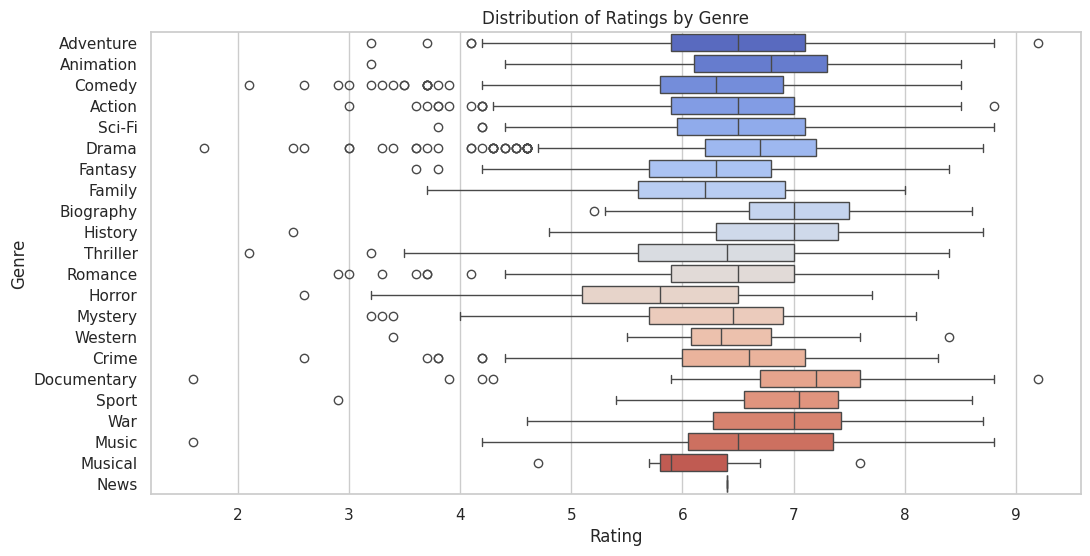

In [55]:
# If genres are separated by '|', split and explode
movies_exploded = movies.copy()
movies_exploded = movies_exploded.assign(genres=movies_exploded['genres'].str.split('|')).explode('genres')

plt.figure(figsize=(12,6))
sns.boxplot(x='rating', y='genres', data=movies_exploded, palette='coolwarm')
plt.xlabel("Rating")
plt.ylabel("Genre")
plt.title("Distribution of Ratings by Genre")
plt.show()

### 2. Popularity by Genre

Which genres and themes attract the largest audiences?

In [89]:
# Check the distribution of genres in the dataset to understand the variety of movies we have
# The `genres` column contains multiple genres separated by commas,
# so we will split the genres into separate rows to analyze the distribution of each genre more effectively.
movies['genres'] = movies['genres'].str.split(',')
movies = movies.explode('genres')
movies['genres'] = movies['genres'].str.strip()

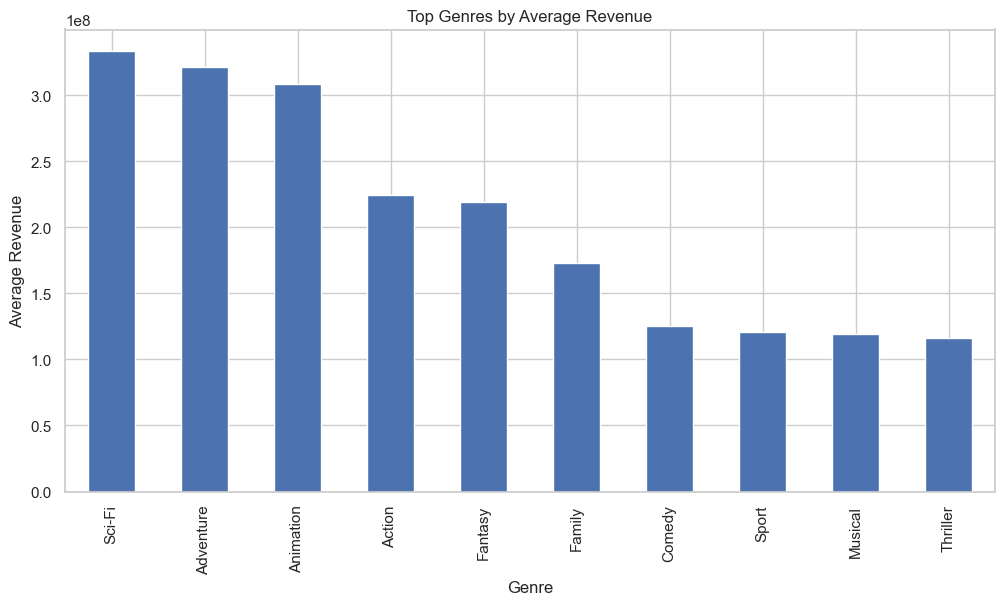

In [90]:
# Visualize the average revenue by genre to identify which genres tend to perform better at the box office.
genre_rev = movies.groupby('genres')['total_gross'].mean().sort_values(ascending=False)
# Plot the top 10 genres by average revenue
genre_rev.head(10).plot(kind='bar', figsize=(12,6))
plt.title("Top Genres by Average Revenue")
plt.xlabel("Genre")
plt.ylabel("Average Revenue")
plt.show()

### 3. Seasonality


Which months or seasons generate the highest box office revenues?


We analyze the seasonality of movie releases by examining how box office revenue varies across different times of the year. Using the release_date column from the budget dataset, we convert it into a datetime format and extract the release month. This allows us to evaluate patterns in revenue distribution throughout the year and identify periods when films tend to perform better at the box office.

In [91]:
# Analyze the seasonality of movie releases by looking at the distribution of release months
# to see if there are certain times of the year when more revenue is generated.
budget['release_date'] = pd.to_datetime(budget['release_date'], errors='coerce')
# Extract the month from the release date to analyze seasonality
budget['release_month'] = budget['release_date'].dt.month

In [92]:
# Create a new column `season` based on the `release_month` to categorize movies into seasons
# (Winter, Spring, Summer, Fall).
# We will define a function `get_season` that takes the month as input and returns the 
# corresponding season,then apply this function to the `release_month` column to create
# the new `season` column.
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

budget['season'] = budget['release_month'].apply(get_season)

In [93]:
# Analyze the average worldwide gross revenue by season to see if there are certain seasons 
# that tend to generate more revenue at the box office.
season_revenue = budget.groupby('season')['worldwide_gross'].mean().sort_values(ascending=False)
# Print the average worldwide gross revenue by season to see if there are any noticeable differences 
# in revenue generation across different seasons.
print(season_revenue)

season
Summer    1.134543e+08
Spring    9.853085e+07
Winter    8.083862e+07
Fall      7.560155e+07
Name: worldwide_gross, dtype: float64


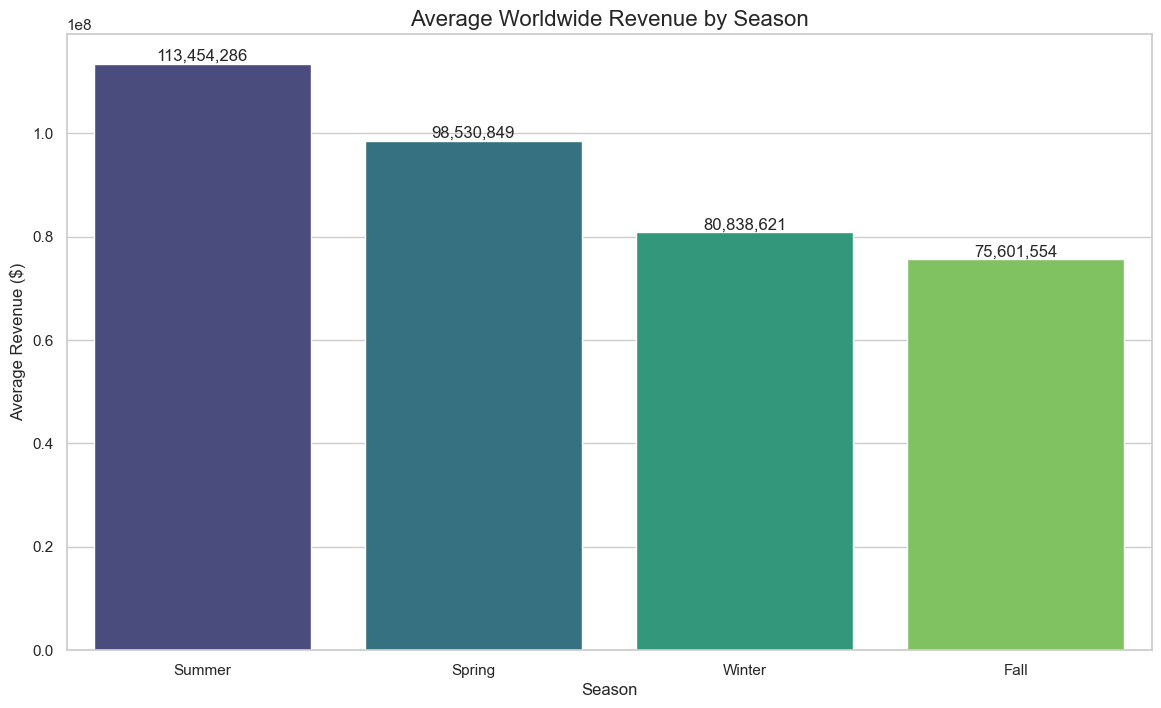

In [94]:
# Visualize the average worldwide gross revenue by season using a bar plot
# to easily compare the performance of movies released in different seasons.
plt.figure(figsize=(14,8))
ax = sns.barplot(
    x=season_revenue.index,
    y=season_revenue.values,
    hue=season_revenue.index,
    palette='viridis',
    legend=False
)
# Add labels on top of the bars to show the exact average revenue values for each season
# We will loop through the bars in the plot and use the `text` method to add the average 
# revenue values on top of each bar for better readability.
for i, v in enumerate(season_revenue.values):
    ax.text(i, v, f"{v:,.0f}", ha='center', va='bottom')
# Set the title and labels for the plot to provide context and improve readability.
plt.title("Average Worldwide Revenue by Season", fontsize=16)
plt.xlabel("Season")
plt.ylabel("Average Revenue ($)")
plt.show()

#### 4. Return on Investment (ROI)

How does production budget influence box office revenue?
We analyze the Box Office Mojo and The Numbers datasets to maximize Return on Investment by comparing production spending and revenue.

To analyze the relationship between production investment and box office performance, we utilize the production_budget and worldwide_gross columns from the budget dataset. The budget DataFrame is merged with the movies DataFrame using the movie title as the key, allowing us to incorporate budget information for each film. This combined dataset enables us to examine how production budgets influence worldwide gross revenue and to visualize the relationship between investment levels and financial success.


In [118]:
# Merge the budget data with the movies DataFrame to bring in the production budget 
# and worldwide gross revenue for each movie
movies = movies.drop(columns=['production_budget', 'worldwide_gross'], errors='ignore')


In [ ]:
# We will perform a left merge to keep all movies in the `movies` DataFrame and bring in the budget information where available.
movies = pd.merge(
    movies,
    budget[['movie', 'production_budget', 'worldwide_gross']],
    left_on='title',
    right_on='movie',
    how='left'
)

In [123]:
# Convert the `production_budget` and `worldwide_gross` columns to numeric values,
# coercing errors to NaN
movies['production_budget_y'] = pd.to_numeric(movies['production_budget_y'], errors='coerce')
movies['worldwide_gross_y'] = pd.to_numeric(movies['worldwide_gross_y'], errors='coerce')

# Drop rows with missing budget or gross
movies_clean = movies.dropna(subset=['production_budget_y', 'worldwide_gross_y'])

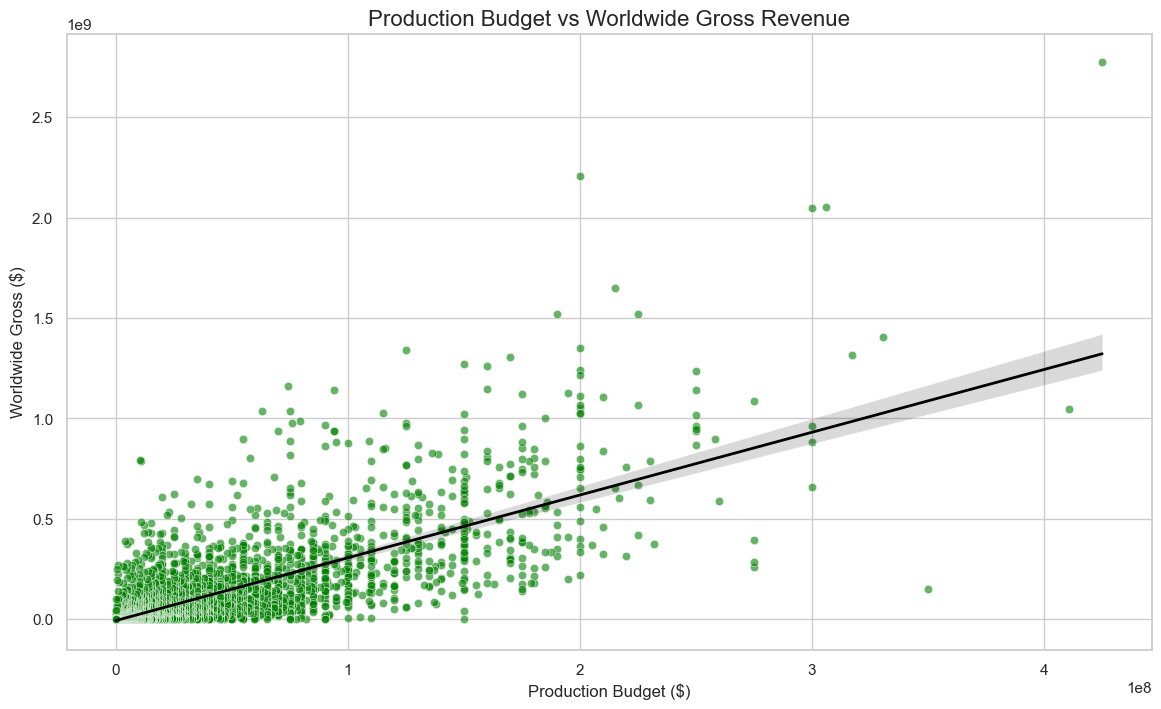

In [141]:
# Plot the relationship between production budget and worldwide gross revenue using 
# a scatter plot with a regression line to visualize the overall trend.
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=movies_clean,
    x='production_budget_y',
    y='worldwide_gross_y',
    alpha=0.6,
    color='green'
)
sns.regplot(
    data=movies_clean,
    x='production_budget_y',
    y='worldwide_gross_y',
    scatter=False,
    color='black',
    line_kws={"linewidth":2}
)
plt.title("Production Budget vs Worldwide Gross Revenue", fontsize=16)
plt.xlabel("Production Budget ($)", fontsize=12)
plt.ylabel("Worldwide Gross ($)", fontsize=12)
plt.show()

In [134]:
# Calculate ROI and add it as a new column in the DataFrame
movies_clean['ROI'] = (movies_clean['worldwide_gross_y'] - movies_clean['production_budget_y']) / movies_clean['production_budget_y']
movies_clean.head()

,title,studio,domestic_gross,foreign_gross,year_x,total_gross,movie_id,original_title,year_y,runtime,...,production_budget_x,worldwide_gross_x,movie_y,production_budget_y,worldwide_gross_y,movie,production_budget,worldwide_gross,ROI,ROI_percent
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Avatar,425000000.0,2.776345e+09,NaN,NaN,NaN,5.532577,553.257713
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Pirates of the Caribbean: On Stranger Tides,410600000.0,1.045664e+09,NaN,NaN,NaN,1.546673,154.667286
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Dark Phoenix,350000000.0,1.497624e+08,NaN,NaN,NaN,-0.572108,-57.210757
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Avengers: Age of Ultron,330600000.0,1.403014e+09,NaN,NaN,NaN,3.243841,324.384139
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Star Wars Ep. VIII: The Last Jedi,317000000.0,1.316722e+09,NaN,NaN,NaN,3.153696,315.369636


In [128]:
movies_clean[['production_budget_y', 'worldwide_gross_y', 'ROI']].head()

,production_budget_y,worldwide_gross_y,ROI
0,425000000.0,2.776345e+09,5.532577
1,410600000.0,1.045664e+09,1.546673
2,350000000.0,1.497624e+08,-0.572108
3,330600000.0,1.403014e+09,3.243841
4,317000000.0,1.316722e+09,3.153696


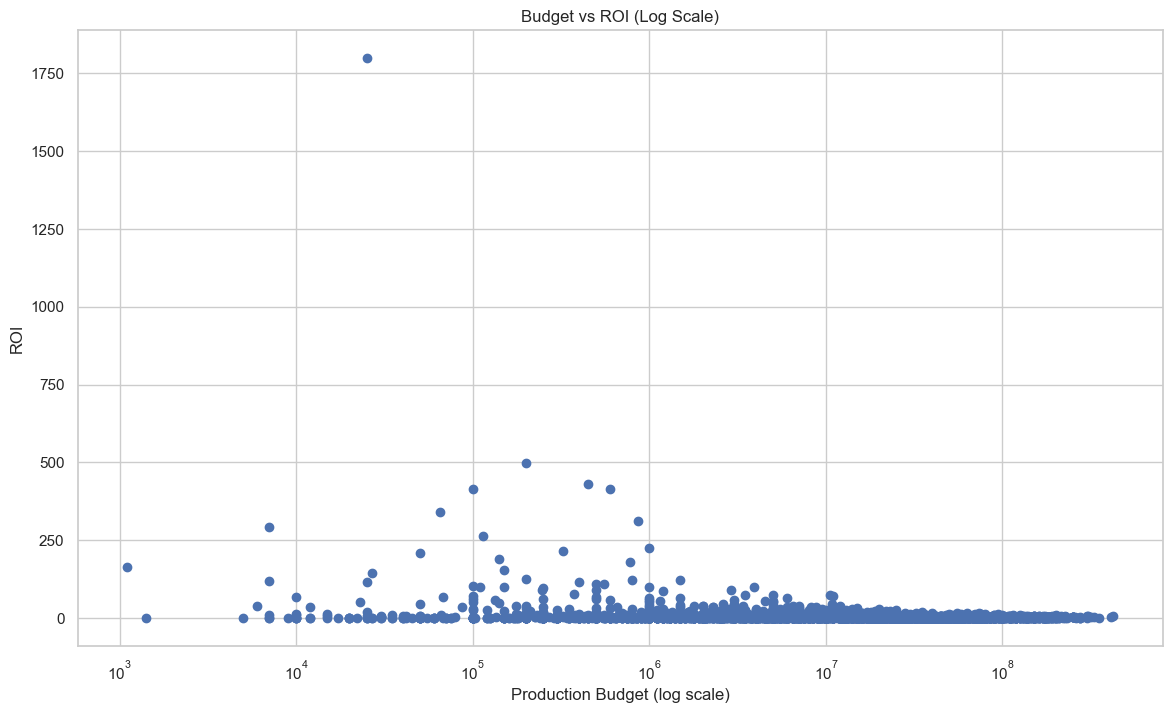

In [142]:
plt.figure(figsize= (14, 8))

plt.scatter(
    movies_clean['production_budget_y'],
    movies_clean['ROI']
)

plt.xscale('log')

plt.xlabel('Production Budget (log scale)')
plt.ylabel('ROI')
plt.title('Budget vs ROI (Log Scale)')

plt.show()

In [133]:
# Top profitable movies
movies_clean.sort_values(by='ROI', ascending=False).head(10)

# Average ROI
movies_clean['ROI'].mean()


np.float64(3.799182468933497)

In [132]:
movies_clean.sort_values(by='ROI', ascending=False).head(10)

,title,studio,domestic_gross,foreign_gross,year_x,total_gross,movie_id,original_title,year_y,runtime,...,production_budget_x,worldwide_gross_x,movie_y,production_budget_y,worldwide_gross_y,movie,production_budget,worldwide_gross,ROI,ROI_percent
5750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Deep Throat,25000.0,45000000.0,NaN,NaN,NaN,1799.000000,179900.000000
5618,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Mad Max,200000.0,99750000.0,NaN,NaN,NaN,497.750000,49775.000000
5497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Paranormal Activity,450000.0,194183034.0,NaN,NaN,NaN,430.517853,43051.785333
5684,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,The Gallows,100000.0,41656474.0,NaN,NaN,NaN,415.564740,41556.474000
5411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,The Blair Witch Project,600000.0,248300000.0,NaN,NaN,NaN,412.833333,41283.333333
5714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Super Size Me,65000.0,22233808.0,NaN,NaN,NaN,341.058585,34105.858462
5351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Bambi,858000.0,268000000.0,NaN,NaN,NaN,311.354312,31135.431235
5778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,El Mariachi,7000.0,2041928.0,NaN,NaN,NaN,290.704000,29070.400000
5681,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Night of the Living Dead,114000.0,30087064.0,NaN,NaN,NaN,262.921614,26292.161404
5215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Rocky,1000000.0,225000000.0,NaN,NaN,NaN,224.000000,22400.000000
